In [206]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [207]:
def f(x):
  return 3*x**2 - 4*x + 5

In [208]:
f(3)

20

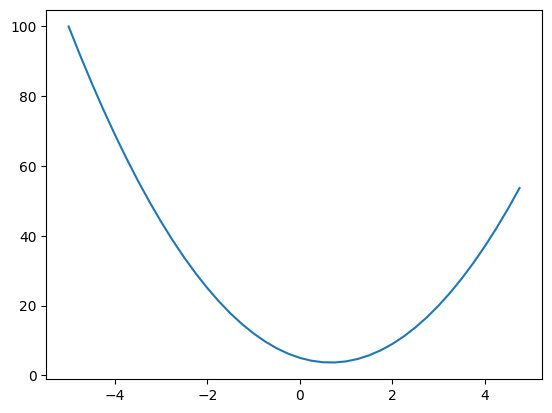

In [209]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

In [210]:
h = 0.00000001
x = -3.0
(f(x+h) - f(x))/h

-22.00000039920269

In [211]:
class Value:

 def __init__(self, data, _children=(), _op='' , label = ''):
  self.data = data
  self.grad = 0.0
  self._prev = set(_children)
  self._op = _op
  self.label = label
 def __repr__(self):
  return f"Value(data={self.data})"
 def __add__(self,other):
  out = Value(self.data + other.data , (self,other) , '+')
  return out
 def __mul__(self,other):
  out = Value(self.data*other.data , (self,other) , '*')
  return out
 def __truediv__(self,other):
  out = Value(self.data/other.data , (self, other) , '/')
  return out
 def tanh(self):
  n = self.data
  t = ((math.exp(2*x) -1)/(math.exp(2*x) +1))
  out = Value(t , (self,) ,'tanh')
  return out


a = Value(2.0 , label  = 'a')
b = Value(-3.0 , label = 'b')
c = Value(10.0 , label  = 'c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
d
f = Value(-2.0 , label = 'f')
L = d*f; L.label = 'L'
L


Value(data=-8.0)

In [212]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data , n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

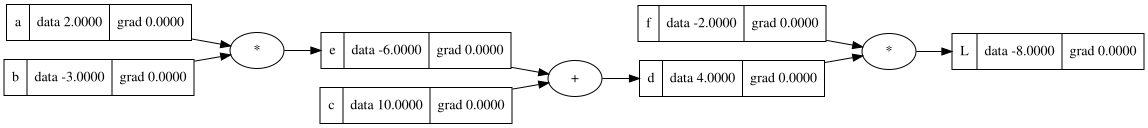

In [213]:
draw_dot(L)

In [214]:
L.data

-8.0

In [215]:
L.grad = 1.0
f.grad = 9.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
b.grad = -4.0
a.grad = 6.0

In [216]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f

L.data


-7.100616

In [217]:
def lol():
  h = 0.0001
  a = Value(2.0 , label  = 'a')
  b = Value(-3.0 , label = 'b')
  c = Value(10.0 , label  = 'c')
  e = a*b; e.label = 'e'
  d = e+c; d.label = 'd'
  d
  f = Value(-2.0 , label = 'f')
  L = d*f; L.label = 'L'
  L1 = L.data

  a = Value(2.0 , label  = 'a')

  b = Value(-3.0 , label = 'b')

  c = Value(10.0 , label  = 'c')
  e = a*b; e.label = 'e'
  d = e+c; d.label = 'd'

  f = Value(-2.0 , label = 'f')
  L = d*f; L.label = 'L'
  L2 = L.data

  print((L2 -L1)/h)

lol()


0.0


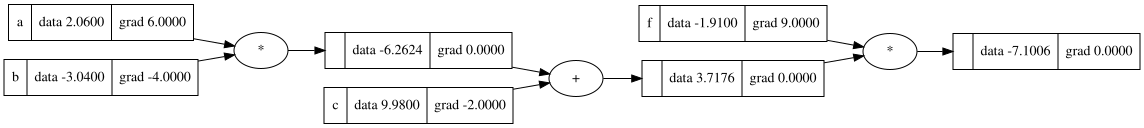

In [218]:
draw_dot(L)

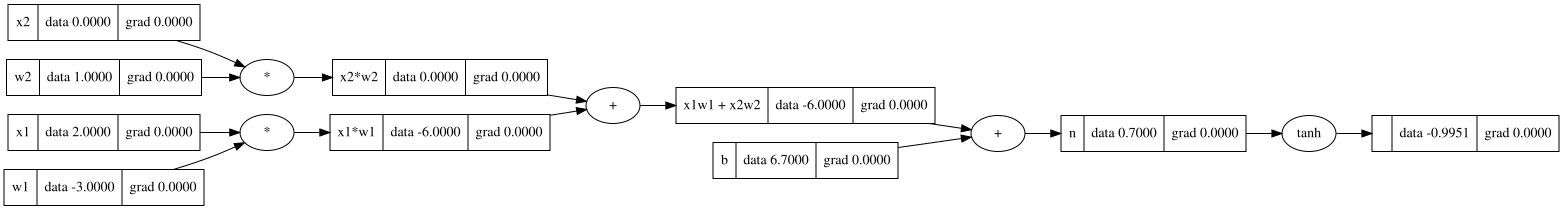

In [219]:
# inputs are x1,x2
x1 = Value(2.0 , label='x1')
x2 = Value(0.0 , label ='x2')
# weights are  w1,w2
w1 = Value(-3.0 , label = 'w1')
w2 = Value(1.0 , label = 'w2')
# biases is b
b = Value(6.7 , label ='b')
# X1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b ; n.label = 'n'
o = n.tanh()
draw_dot(o)
